2.3.1 Загрузка данных и первичный анализ

1. Импортировать необходимые библиотеки:
   - `pandas` и, при необходимости, `numpy`;
   - модули из `scikit-learn`: `train_test_split`, `DummyClassifier`, `LogisticRegression`, `Pipeline`, `StandardScaler`, метрики (`accuracy_score`, `roc_auc_score` и т.п.);
   - при желании – `matplotlib`/`seaborn` для графиков.

In [2]:
# Базовые библиотеки для данных
import pandas as pd
import numpy as np

# Разделение данных на train/test
from sklearn.model_selection import train_test_split

# Модели
from sklearn.dummy import DummyClassifier      # Базовая модель (сравнение)
from sklearn.linear_model import LogisticRegression  # Логистическая регрессия

# Pipeline + предобработка
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # Нормализация

# Метрики качества
from sklearn.metrics import (
    accuracy_score,           # Точность (% правильных предсказаний)
    roc_auc_score,            # AUC ROC (качество ранжирования)
    classification_report,    # Полная статистика (precision, recall, F1)
    confusion_matrix          # Матрица ошибок
)

# Визуализация (опционально)
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
plt.style.use('default')
sns.set_palette("husl")


ModuleNotFoundError: No module named 'pandas'

2. Загрузить датасет `S05-hw-dataset.csv` в `pandas.DataFrame` с помощью `pd.read_csv`.

3. Вывести и проанализировать:
   - первые строки датасета (`head()`),
   - информацию о столбцах и типах (`info()`),
   - базовые описательные статистики для числовых признаков (`describe()` или аналог),
   - распределение целевого признака `default` (например, через `value_counts(normalize=True)`).


In [11]:
df = pd.read_csv(r'seminars/S05-hw-dataset.csv')

print(df.head())
print(df.info())
print(df.describe())

if 'default' in df.columns:
    print(df['default'].value_counts(normalize=True))
    print(df['default'].value_counts())
else:
    print("Столбец 'default' не найден")
    
print(df.isnull().sum())


   client_id  age  income  years_employed  credit_score  debt_to_income  \
0          1   25   94074              22           839        0.547339   
1          2   58   51884              26           565        0.290882   
2          3   53   48656              39           561        0.522340   
3          4   42   81492              30           582        0.709123   
4          5   42   94713               8           642        0.793392   

   num_credit_cards  num_late_payments  has_mortgage  has_car_loan  \
0                 1                  7             0             0   
1                 1                  1             0             1   
2                 1                 13             0             0   
3                 2                 10             1             1   
4                 3                  3             0             0   

   savings_balance  checking_balance  region_risk_score  \
0            26057              5229           0.080052   
1         

In [13]:
print(f"Размер: {df.shape[0]} объектов, {df.shape[1]} признаков")

print("\n", "Распределение 'default':")
print(df['default'].value_counts(normalize=True).round(3))

print("\n", "Аномалии:")
print(f"Возраст <18: {(df['age'] < 18).sum()}")
print(f"Доход <0: {(df['income'] < 0).sum()}")
print(f"Стаж работы > возраста: {(df['years_employed'] > df['age']).sum()}")

Размер: 3000 объектов, 17 признаков

 Распределение 'default':
default
0    0.59
1    0.41
Name: proportion, dtype: float64

 Аномалии:
Возраст <18: 0
Доход <0: 0
Стаж работы > возраста: 276


Довольно много пользователей со стажем больше их собственного возраста

2.3.2. Подготовка признаков и таргета

In [15]:
# 1. Выделение признаков и таргета
X = df.drop(['client_id', 'default'], axis=1)
y = df['default']

# 2. Проверка типов данных на всякий случай
print("Типы признаков:")
print(X.dtypes)

# 3. Проверка диапазонов ключевых признаков
print("\nДиапазоны:")
print(f"debt_to_income: [{X['debt_to_income'].min():.3f}, {X['debt_to_income'].max():.3f}]")
print(f"age: [{X['age'].min():.0f}, {X['age'].max():.0f}]")

# 4. Размерности
print(f"\nРазмерности: X={X.shape}, y={y.shape}")


Типы признаков:
age                                 int64
income                              int64
years_employed                      int64
credit_score                        int64
debt_to_income                    float64
num_credit_cards                    int64
num_late_payments                   int64
has_mortgage                        int64
has_car_loan                        int64
savings_balance                     int64
checking_balance                    int64
region_risk_score                 float64
phone_calls_to_support_last_3m      int64
active_loans                        int64
customer_tenure_years               int64
dtype: object

Диапазоны:
debt_to_income: [0.006, 0.878]
age: [21, 69]

Размерности: X=(3000, 15), y=(3000,)


2.3.3. Train/Test-сплит и бейзлайн-модель

1. Разделить данные на обучающую и тестовую выборки:
   - использовать `train_test_split` из `sklearn.model_selection`;
   - разумное соотношение, например `test_size=0.2` или `0.25`;
   - важно: зафиксировать `random_state` (например, `random_state=42`), чтобы результаты были воспроизводимыми;
   - рекомендуется использовать `stratify=y`, чтобы сохранить баланс классов.

2. Построить **бейзлайн-модель** на основе `DummyClassifier`:
   - например, `strategy="most_frequent"` или `strategy="stratified"`;
   - обучить её на обучающей выборке (`fit(X_train, y_train)`).

3. Оценить бейзлайн по крайней мере по двум метрикам:
   - `accuracy` на тестовой выборке;
   - `ROC-AUC` на тестовой выборке (если используете `predict_proba` или `decision_function`).

4. Вывести значения метрик и коротко прокомментировать, что делает бейзлайн и почему важно иметь точку отсчёта.

In [ ]:
# 1. Train/Test сплит
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Бейзлайн модель
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

# 3. Предсказания и метрики
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred_baseline = baseline.predict(X_test)
y_pred_proba_baseline = baseline.predict_proba(X_test)[:, 1]

acc_baseline = accuracy_score(y_test, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)

print(df['default'].value_counts(normalize=True))

# 2. Бейзлайн Accuracy
from sklearn.metrics import accuracy_score
dummy_pred = [0] * len(y_test)  # Всегда "НЕ дефолт"
print("Бейзлайн Accuracy:", accuracy_score(y_test, dummy_pred))

# 3. Бейзлайн ROC-AUC  
dummy_proba = [0.5] * len(y_test)
print("Бейзлайн ROC-AUC:", roc_auc_score(y_test, dummy_proba))




default
0    0.589667
1    0.410333
Name: proportion, dtype: float64
Бейзлайн Accuracy: 0.59
Бейзлайн ROC-AUC: 0.5


11

C=0.01: ROC-AUC=0.875
C=0.1: ROC-AUC=0.875
C=1.0: ROC-AUC=0.876
C=10.0: ROC-AUC=0.876
Лучший гипперпараметр: 10.0
Точность: 0.800
Полезность модели:  0.876


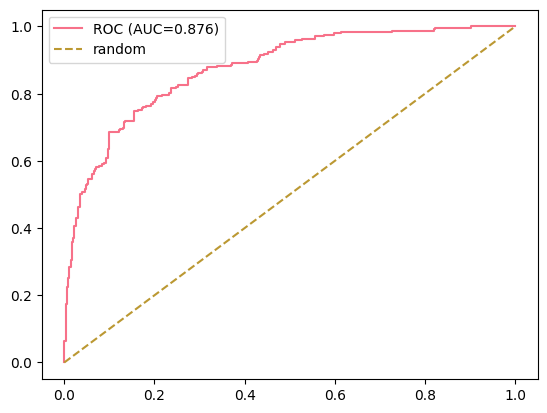

In [46]:
import os
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

C_values = [0.01, 0.1, 1.0, 10.0]
best_C = C_values[0]
best_roc = 0

for C in C_values:
    pipe.set_params(logreg__C=C)
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)
    print(f"C={C}: ROC-AUC={roc:.3f}")
    if roc > best_roc:
        best_roc = roc
        best_C = C

pipe.set_params(logreg__C=best_C)
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred)
roc_auc_logreg = roc_auc_score(y_test, y_proba)

print(f"Лучший гипперпараметр: {best_C}")
print(f"Точность: {accuracy_score(y_test, y_pred):.3f}")
print(f"Полезность модели:  {roc_auc_score(y_test, y_proba):.3f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='random')
plt.legend()

os.makedirs('figures/', exist_ok=True)
plt.savefig('figures/grafikrafik.png', dpi=300, bbox_inches='tight')
plt.show()


1

In [45]:
import pandas as pd

results = pd.DataFrame({
    'Способы': ['Dummy(most_frequent)', 'LogisticRegression'],
    'Точность': [acc_baseline, acc_logreg],
    'Полезность': [roc_auc_baseline, roc_auc_logreg]
})

results


,Способы,Точность,Полезность
0,Dummy(most_frequent),0.59,0.500000
1,LogisticRegression,0.80,0.875637


Логистическая регрессия более полезна и точнее чем бейзлайн в данном случае. При изменения С в логистической регрессии результат почти не менялся.